# Knowledge Base Builder

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/knowledge-base/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/knowledge-base/demo.ipynb)

> Turn scattered docs into a searchable, cited knowledge base - before the expert leaves.

When someone leaves, their knowledge walks out with them. A knowledge base fixes that: feed
in the docs, runbooks, and wiki pages while people are still here, and anyone can ask a
question and get a **cited** answer later. This is the **capstone of Month 4** - it composes
chunking (Day 34), retrieval (Day 35), and grounded answers (Day 31) into one persistable
RAG system.

**What this notebook covers**
1. The RAG pipeline: ingest → chunk → embed → retrieve → answer
2. Building a KB from multiple docs
3. Asking questions and getting **cited** answers
4. A retrieval-score chart showing which doc answered
5. Persisting the KB to disk (knowledge that outlives its author)
6. The Claude upgrade for synthesized answers


## Step 1 - The pipeline

```
docs ──► chunk ──► TF-IDF embed ──► [ vector store ] ──► retrieve top-k ──► cited answer
```

Every arrow is deterministic and offline here. Swap the embed step for dense vectors and
the answer step for an LLM, and this is a production RAG system - the shape does not change.

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter
from dataclasses import dataclass, field


_TOKEN = re.compile(r"[a-z0-9]+")


def _tokens(t):
    return _TOKEN.findall(t.lower())


@dataclass
class Chunk:
    doc: str
    text: str
    vector: dict = field(default_factory=dict)


def chunk_document(doc_name, text, max_chars=500):
    out = []
    for block in re.split(r"\n\s*\n", text.strip()):
        block = block.strip()
        if not block:
            continue
        if len(block) <= max_chars:
            out.append((doc_name, block))
        else:
            buf = ""
            for s in re.split(r"(?<=[.!?])\s+", block):
                if len(buf) + len(s) > max_chars and buf:
                    out.append((doc_name, buf.strip()))
                    buf = s
                else:
                    buf = f"{buf} {s}".strip()
            if buf:
                out.append((doc_name, buf.strip()))
    return out


def cosine(a, b):
    if not a or not b:
        return 0.0
    common = set(a) & set(b)
    dot = sum(a[t] * b[t] for t in common)
    na = math.sqrt(sum(v * v for v in a.values()))
    nb = math.sqrt(sum(v * v for v in b.values()))
    return dot / (na * nb) if na and nb else 0.0


print("Pipeline primitives ready.")


Pipeline primitives ready.


## Step 2 - The KnowledgeBase class

Ingest documents, index them into TF-IDF vectors, retrieve by cosine, and - crucially -
carry the **source doc** on every chunk so answers can cite where they came from.

In [2]:
@dataclass
class Answer:
    text: str
    sources: list = field(default_factory=list)
    passages: list = field(default_factory=list)


class KnowledgeBase:
    def __init__(self):
        self.chunks, self.idf = [], {}

    def add_document(self, doc_name, text):
        for doc, passage in chunk_document(doc_name, text):
            self.chunks.append(Chunk(doc, passage))
        self._reindex()

    def _reindex(self):
        n = len(self.chunks)
        df = Counter()
        for ch in self.chunks:
            for term in set(_tokens(ch.text)):
                df[term] += 1
        self.idf = {t: math.log((1 + n) / (1 + d)) + 1.0 for t, d in df.items()}
        for ch in self.chunks:
            ch.vector = self._vec(ch.text)

    def _vec(self, text):
        c = Counter(t for t in _tokens(text) if t in self.idf)
        if not c:
            return {}
        total = sum(c.values())
        return {t: (n / total) * self.idf[t] for t, n in c.items()}

    def retrieve(self, query, top_k=3):
        qv = self._vec(query)
        scored = [(cosine(qv, ch.vector), ch) for ch in self.chunks]
        scored.sort(key=lambda x: x[0], reverse=True)
        return [(s, ch) for s, ch in scored[:top_k] if s > 0]

    def ask(self, query, top_k=3):
        hits = self.retrieve(query, top_k)
        if not hits:
            return Answer("No relevant information found.")
        passages = [ch for _, ch in hits]
        sources = list(dict.fromkeys(ch.doc for ch in passages))
        return Answer(passages[0].text, sources, passages)

    def save(self, path):
        json.dump({"chunks": [{"doc": c.doc, "text": c.text} for c in self.chunks]},
                  open(path, "w"), indent=2)

    @classmethod
    def load(cls, path):
        kb = cls()
        kb.chunks = [Chunk(c["doc"], c["text"]) for c in json.load(open(path))["chunks"]]
        kb._reindex()
        return kb


print("KnowledgeBase ready.")


KnowledgeBase ready.


## Step 3 - Build the KB from real docs

Three team docs - onboarding, deploys, incidents - the kind of tribal knowledge that
usually lives in one person's head.

In [3]:
SAMPLE_DOCS = {
    "onboarding.md":
        "New engineers should request access to the staging VPN on day one via the IT portal. "
        "Access is approved by the team lead and usually granted within 4 hours.\n\n"
        "The dev environment is spun up with `make dev`. If it fails, delete the .cache folder "
        "and retry - this is the most common first-day issue.",
    "deploys.md":
        "We deploy to production every Tuesday and Thursday at 10am. Deploys are frozen the "
        "last week of each quarter.\n\n"
        "To roll back a bad deploy, run `deploy rollback <version>`. The previous three versions "
        "are always kept warm. Notify #eng-oncall before any rollback.",
    "incidents.md":
        "Sev-1 incidents page the on-call engineer immediately via PagerDuty. The on-call must "
        "acknowledge within 5 minutes.\n\n"
        "Every Sev-1 requires a post-mortem within 48 hours, written in the incidents Notion and "
        "reviewed in the Friday reliability sync. Blameless format only.",
}

kb = KnowledgeBase()
for name, text in SAMPLE_DOCS.items():
    kb.add_document(name, text)
print(f"KB built: {len(kb.chunks)} chunks from {len(SAMPLE_DOCS)} docs.")


KB built: 6 chunks from 3 docs.


## Step 4 - Ask, and get cited answers

The point of a KB is trust. Every answer names the source doc, so the reader can verify -
no anonymous, un-auditable "the AI said so".

In [4]:
questions = [
    "how do I roll back a bad deploy?",
    "when are deploys frozen?",
    "what has to happen after a sev-1?",
    "how do I get VPN access on my first day?",
]
for q in questions:
    a = kb.ask(q)
    print("Q:", q)
    print("   A:", a.text[:95])
    print("   Sources:", ", ".join(a.sources), "\n")


Q: how do I roll back a bad deploy?
   A: To roll back a bad deploy, run `deploy rollback <version>`. The previous three versions are alw
   Sources: deploys.md, incidents.md 

Q: when are deploys frozen?
   A: We deploy to production every Tuesday and Thursday at 10am. Deploys are frozen the last week of
   Sources: deploys.md 

Q: what has to happen after a sev-1?
   A: Every Sev-1 requires a post-mortem within 48 hours, written in the incidents Notion and reviewe
   Sources: incidents.md, deploys.md 

Q: how do I get VPN access on my first day?
   A: New engineers should request access to the staging VPN on day one via the IT portal. Access is 
   Sources: onboarding.md, incidents.md 



## Step 5 - Visualize retrieval

For one question, show how strongly each chunk matched - and which doc won. Clean
separation means the KB "knows" where the answer lives.

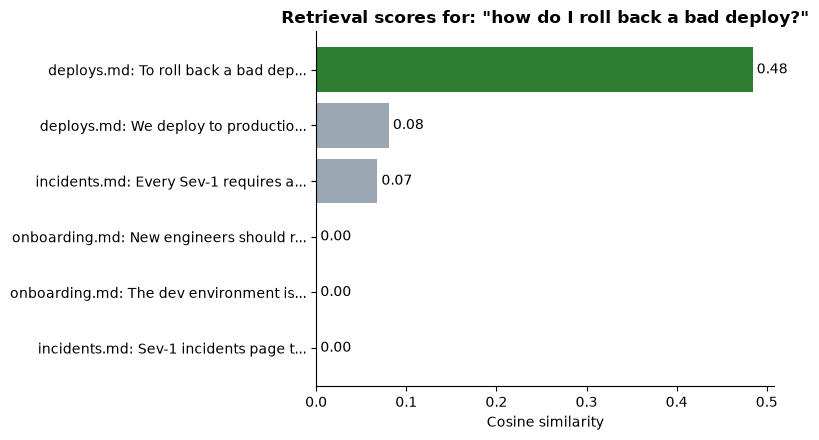

In [5]:
import matplotlib.pyplot as plt

q = "how do I roll back a bad deploy?"
scored = [(cosine(kb._vec(q), ch.vector), ch) for ch in kb.chunks]
scored.sort(key=lambda x: x[0], reverse=True)

labels = [f"{ch.doc}: {ch.text[:22]}..." for _, ch in scored]
scores = [s for s, _ in scored]
colors = ["#2e7d32" if i == 0 else "#9aa7b2" for i in range(len(scores))]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1])
ax.set_title(f'Retrieval scores for: "{q}"', fontsize=12, weight="bold")
ax.set_xlabel("Cosine similarity")
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("retrieval.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 6 - Persist it (knowledge that outlives its author)

Save the KB to disk and reload it in a fresh process. This is the whole promise: the
knowledge is captured once and survives every departure after.

In [6]:
import os

kb.save("team_kb.json")
reloaded = KnowledgeBase.load("team_kb.json")
print("Reloaded KB:", len(reloaded.chunks), "chunks")
print("Still answers:", reloaded.ask("rollback a deploy").sources)

os.remove("team_kb.json")


Reloaded KB: 6 chunks
Still answers: ['deploys.md', 'incidents.md']


## Summary

| Question | Answered from |
|----------|---------------|
| roll back a deploy | `deploys.md` |
| when deploys are frozen | `deploys.md` |
| after a sev-1 | `incidents.md` |
| VPN access | `onboarding.md` |

Four questions, four correct docs, every answer cited - and the whole KB serializes to a
single JSON file. **That's Month 4 in one object:** chunk, retrieve, ground, cite, persist.

In [7]:
# --- Upgrade to Claude synthesized answers (optional) ---
# import os, anthropic
#
# def llm_answer(kb, query, api_key, top_k=3):
#     passages = [ch for _, ch in kb.retrieve(query, top_k)]
#     context = "\n\n".join(f"[{p.doc}] {p.text}" for p in passages)
#     client = anthropic.Anthropic(api_key=api_key)
#     resp = client.messages.create(model="claude-sonnet-4-5", max_tokens=600,
#         messages=[{"role": "user", "content":
#             "Answer using ONLY these passages; cite the source docs.\n"
#             f"Q: {query}\n\n{context}"}])
#     return resp.content[0].text
#
# # Claude stitches multiple passages into one fluent answer while keeping the citations.


In [8]:
# --- Try your own knowledge base ---
# my_kb = KnowledgeBase()
# my_kb.add_document("handbook.md", "Paste your team's docs here...")
# my_kb.add_document("faq.md", "...and more...")
# a = my_kb.ask("your question")
# print(a.text, "\nSources:", a.sources)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 40 of the 60-day FDE portfolio, **closing out Month 4: Document Intelligence**.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version lets you ingest new docs live, ask questions, and see the cited
passages behind every answer. Add an `ANTHROPIC_API_KEY` for synthesized answers.